In [1]:
from pathlib import Path
import shutil
import time

def clean_xpidon_outputs(
    project_root=".",
    backup=True,
    dry_run=True,
):
    """
    Clean old XPIDON training outputs before a new notebook training run.

    Use this BEFORE training.
    Do NOT run this after training and before plotting, otherwise models/loss files will be deleted.

    Parameters
    ----------
    project_root : str
        Project root path. Usually "." if notebook is opened inside XPIDON-Composites.
    backup : bool
        If True, backup current outputs/ and root-level model pkl files before cleaning.
    dry_run : bool
        If True, only print what would be deleted. Set False to actually clean.
    """

    root = Path(project_root).resolve()

    # Safety check: avoid deleting files from wrong directory
    expected_files = ["main.py", "phy_params.json", "exp_params.json", "train_params.json"]
    existing_expected = [f for f in expected_files if (root / f).exists()]

    if len(existing_expected) < 2:
        raise RuntimeError(
            f"Project root may be wrong: {root}\n"
            "Please run this from XPIDON-Composites project root or set project_root correctly."
        )

    print(f"Project root: {root}")
    print(f"Dry run: {dry_run}")
    print(f"Backup: {backup}")

    # Folders generated by training/plotting
    output_subdirs = [
        root / "outputs" / "models",
        root / "outputs" / "loss_data",
        root / "outputs" / "figures",
        root / "outputs" / "predictions",
    ]

    # Root-level files generated by train.py
    root_patterns = [
        "xpidon_class_*_T.pkl",
        "xpidon_class_*_a.pkl",
        "T_temp.pkl",
        "a_temp.pkl",
    ]

    files_to_delete = []
    dirs_to_clean = []

    for folder in output_subdirs:
        folder.mkdir(parents=True, exist_ok=True)
        dirs_to_clean.append(folder)
        for item in folder.iterdir():
            files_to_delete.append(item)

    for pattern in root_patterns:
        files_to_delete.extend(root.glob(pattern))

    files_to_delete = sorted(set(files_to_delete))

    print("\nFiles/folders that will be cleaned:")
    if not files_to_delete:
        print("  Nothing to clean.")
    else:
        for p in files_to_delete:
            print(" ", p.relative_to(root))

    if dry_run:
        print("\nDry run only. Nothing was deleted.")
        print("Run clean_xpidon_outputs(dry_run=False) to actually clean.")
        return

    # Optional backup
    if backup and files_to_delete:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        backup_dir = root / f"outputs_backup_{timestamp}"
        backup_dir.mkdir(parents=True, exist_ok=True)

        print(f"\nCreating backup: {backup_dir.name}")

        # Backup outputs folder
        outputs_dir = root / "outputs"
        if outputs_dir.exists():
            shutil.copytree(outputs_dir, backup_dir / "outputs", dirs_exist_ok=True)

        # Backup root pkl files
        root_pkl_backup = backup_dir / "root_pkl_files"
        root_pkl_backup.mkdir(exist_ok=True)

        for pattern in root_patterns:
            for file in root.glob(pattern):
                if file.is_file():
                    shutil.copy2(file, root_pkl_backup / file.name)

    # Delete contents
    for p in files_to_delete:
        if p.exists():
            if p.is_file() or p.is_symlink():
                p.unlink()
            elif p.is_dir():
                shutil.rmtree(p)

    # Recreate output folders
    for folder in output_subdirs:
        folder.mkdir(parents=True, exist_ok=True)

    print("\nClean complete.")

In [2]:
clean_xpidon_outputs(dry_run=True)

Project root: /Users/luzhang/Projects/XPIDON-Composites
Dry run: True
Backup: True

Files/folders that will be cleaned:
  T_temp.pkl
  a_temp.pkl

Dry run only. Nothing was deleted.
Run clean_xpidon_outputs(dry_run=False) to actually clean.


In [3]:
clean_xpidon_outputs(dry_run=False, backup=True)

Project root: /Users/luzhang/Projects/XPIDON-Composites
Dry run: False
Backup: True

Files/folders that will be cleaned:
  T_temp.pkl
  a_temp.pkl

Creating backup: outputs_backup_20260627_184431

Clean complete.


In [4]:
from utils.phy_params import PhyParams
from utils.exp_params import ExpParams
from utils.train_params import TrainParams
from utils.air_temp import Temp_air
from utils.data_utils import DataGenerator, generate_training_data
from trainer.train import train
from models.pidon import XPIDON
from loss.loss import XPIDONLoss

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB



W0000 00:00:1782549872.773550 5970811 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1782549872.781681 5970811 service.cc:145] XLA service 0x14ff58fe0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782549872.781692 5970811 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1782549872.782651 5970811 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1782549872.782657 5970811 mps_client.cc:384] XLA backend will use up to 17179410432 bytes on device 0 for SimpleAllocator.


In [5]:
params = PhyParams('phy_params.json')
exp_params = ExpParams('exp_params.json')
train_params = TrainParams('train_params.json')
init_sub_domain = 1
Tolerance_level =  2e-2
m_inp = 9
branch_layers = [m_inp, 50, 50, 50, 100]
trunk_layers =  [2, 50, 50, 50, 50, 50, 100]
nomad_layers_T = [100, 50, 50, 50, 50, 1]


--- Processing Sub-domain: 1/1 ---
Time range: 0.00 to 18800.00 seconds


Training Progress:   5%|████████▋                                                                                                                                                                     | 10/200 [03:28<1:06:34, 21.03s/it, Status=** Training T **, Loss T=6.31e+00, Loss a=3.70e-03, ICs T=4.73e-01, ICs tool=4.73e-01, ICs Alpha=6.97e-04, BCs Bot=1.52e-01, BCs Top=1.02e-01, PDE Part=3.12e+00, PDE Tool=1.69e-02, Cure Part=3.00e-03, INF=9.88e-05, FLUX=8.65e-03, T lr=1.00e-03, a lr=5.90e-04]

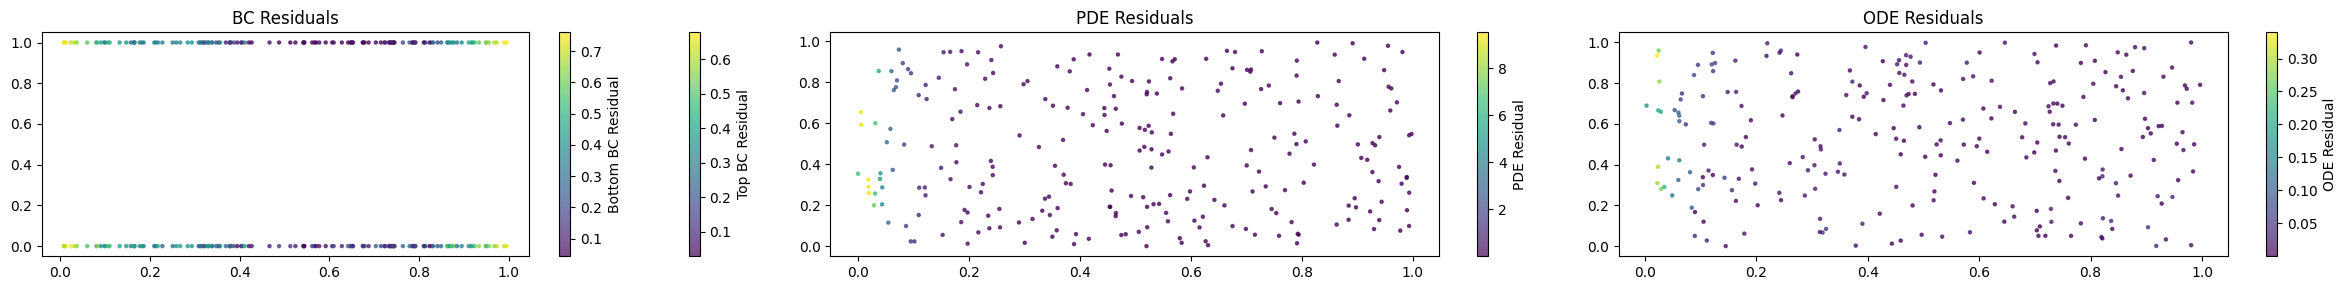

Training Progress:  10%|█████████████████▍                                                                                                                                                            | 20/200 [09:41<1:54:27, 38.15s/it, Status=** Training a **, Loss T=6.55e-03, Loss a=7.63e+00, ICs T=1.49e-05, ICs tool=4.09e-05, ICs Alpha=6.72e-04, BCs Bot=3.23e-04, BCs Top=4.17e-04, PDE Part=1.98e-03, PDE Tool=3.33e-04, Cure Part=7.63e+00, INF=3.18e-04, FLUX=1.26e-04, T lr=5.90e-04, a lr=5.90e-04]

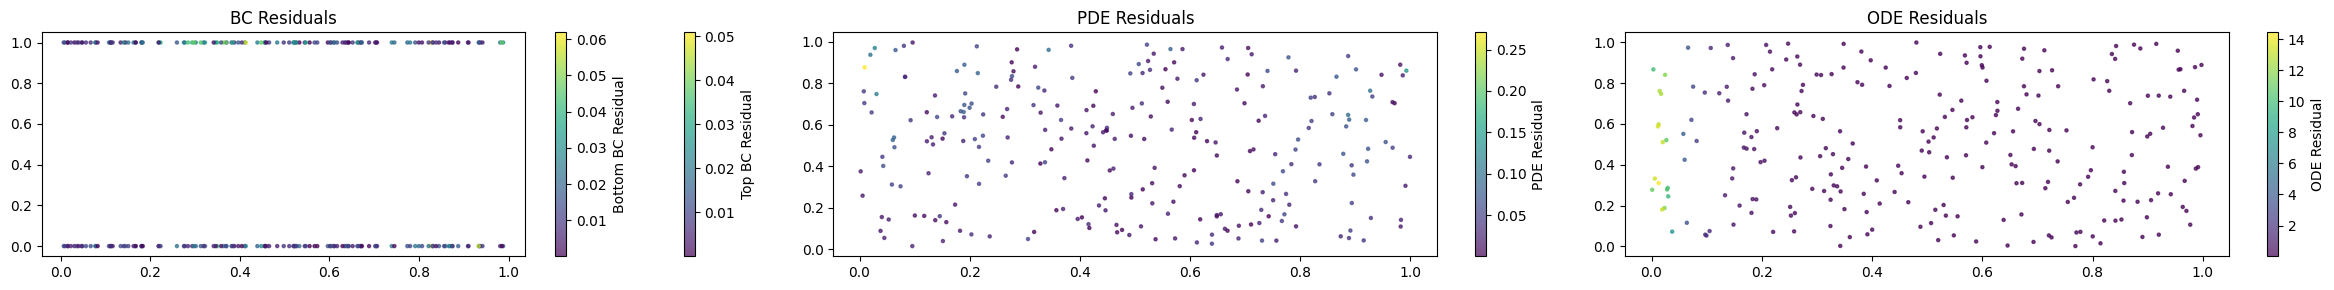

Training Progress:  15%|██████████████████████████                                                                                                                                                    | 30/200 [13:20<1:02:54, 22.20s/it, Status=** Training T **, Loss T=9.90e-01, Loss a=4.30e-04, ICs T=1.74e-05, ICs tool=4.02e-05, ICs Alpha=3.94e-06, BCs Bot=2.46e-04, BCs Top=3.11e-04, PDE Part=9.86e-01, PDE Tool=3.35e-04, Cure Part=4.26e-04, INF=2.69e-04, FLUX=1.47e-04, T lr=5.90e-04, a lr=3.48e-04]

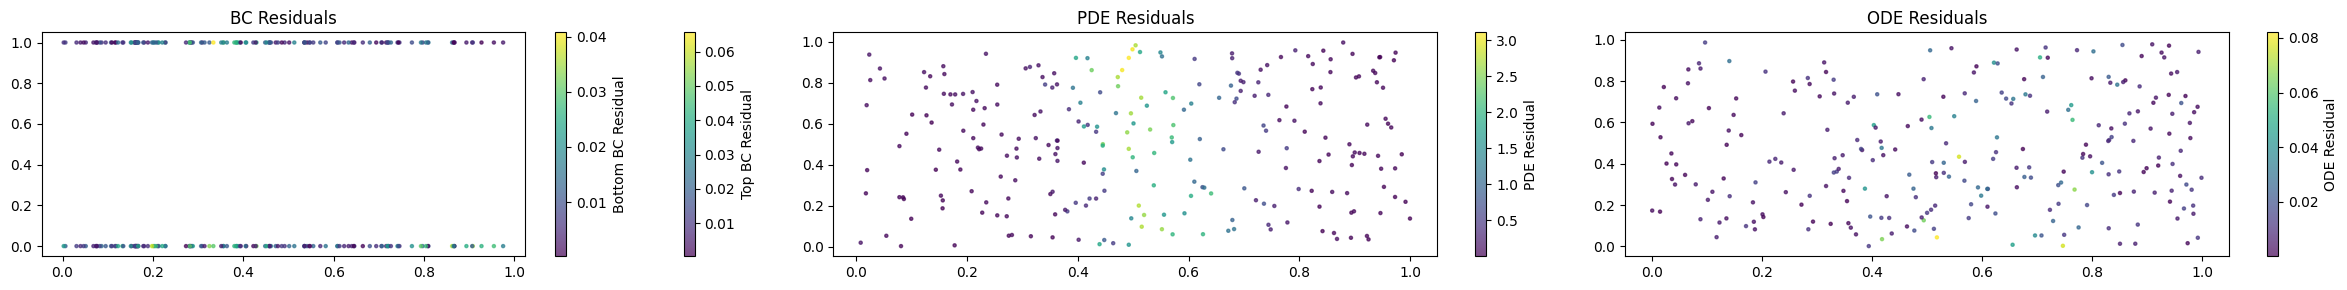

Training Progress:  20%|██████████████████████████████████▊                                                                                                                                           | 40/200 [19:36<1:40:16, 37.60s/it, Status=** Training a **, Loss T=3.82e-03, Loss a=7.82e-02, ICs T=2.02e-05, ICs tool=1.60e-05, ICs Alpha=3.96e-06, BCs Bot=1.22e-04, BCs Top=2.62e-04, PDE Part=6.82e-04, PDE Tool=2.79e-04, Cure Part=7.82e-02, INF=5.05e-04, FLUX=3.57e-04, T lr=3.48e-04, a lr=3.48e-04]

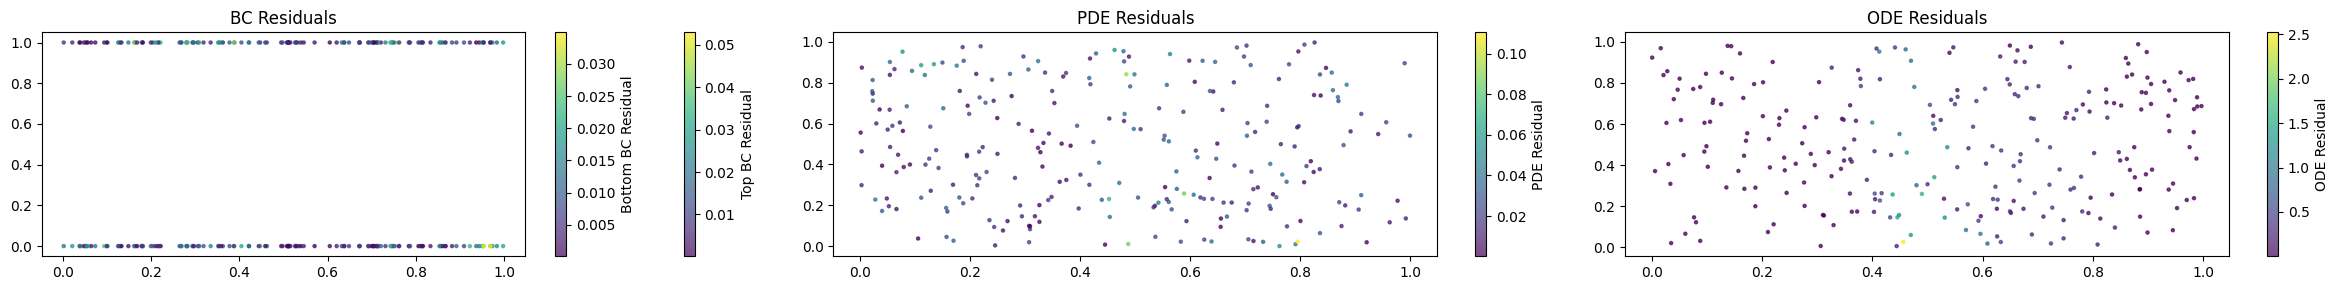

Training Progress:  25%|████████████████████████████████████████████                                                                                                                                    | 50/200 [23:20<55:41, 22.28s/it, Status=** Training T **, Loss T=6.37e-02, Loss a=5.05e-04, ICs T=1.64e-05, ICs tool=1.63e-05, ICs Alpha=1.30e-06, BCs Bot=9.72e-05, BCs Top=2.78e-04, PDE Part=6.06e-02, PDE Tool=3.21e-04, Cure Part=5.04e-04, INF=5.04e-04, FLUX=3.03e-04, T lr=3.48e-04, a lr=2.06e-04]

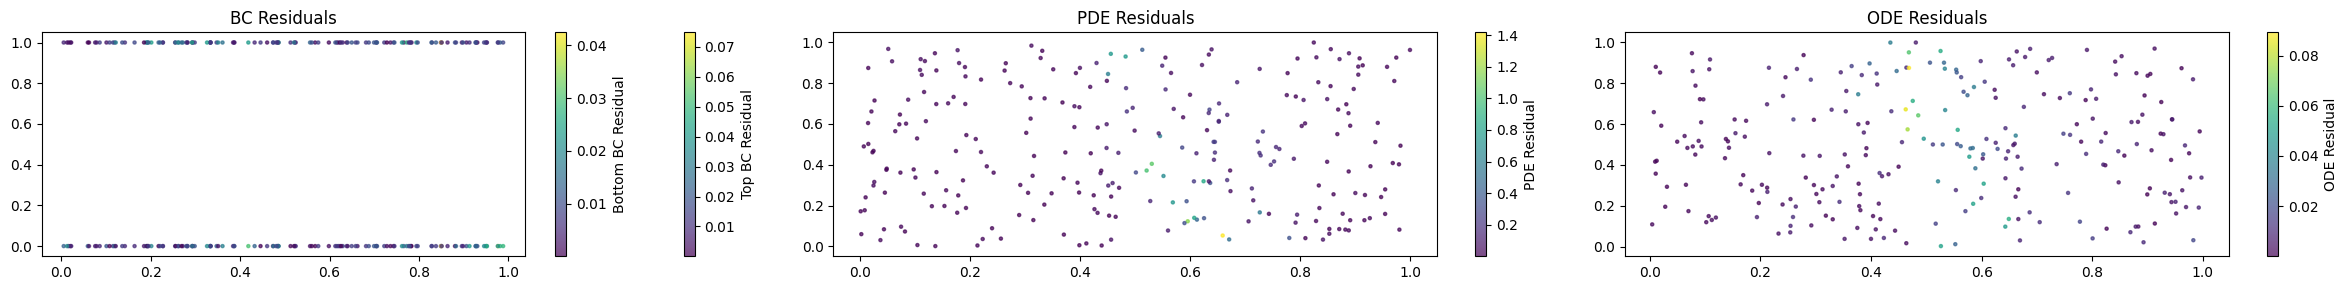

Training Progress:  30%|████████████████████████████████████████████████████▏                                                                                                                         | 60/200 [29:28<1:25:03, 36.46s/it, Status=** Training a **, Loss T=3.60e-03, Loss a=1.96e-02, ICs T=1.15e-05, ICs tool=7.12e-06, ICs Alpha=1.33e-06, BCs Bot=4.12e-05, BCs Top=3.13e-04, PDE Part=6.72e-04, PDE Tool=1.12e-04, Cure Part=1.96e-02, INF=7.82e-04, FLUX=2.18e-04, T lr=2.06e-04, a lr=2.06e-04]

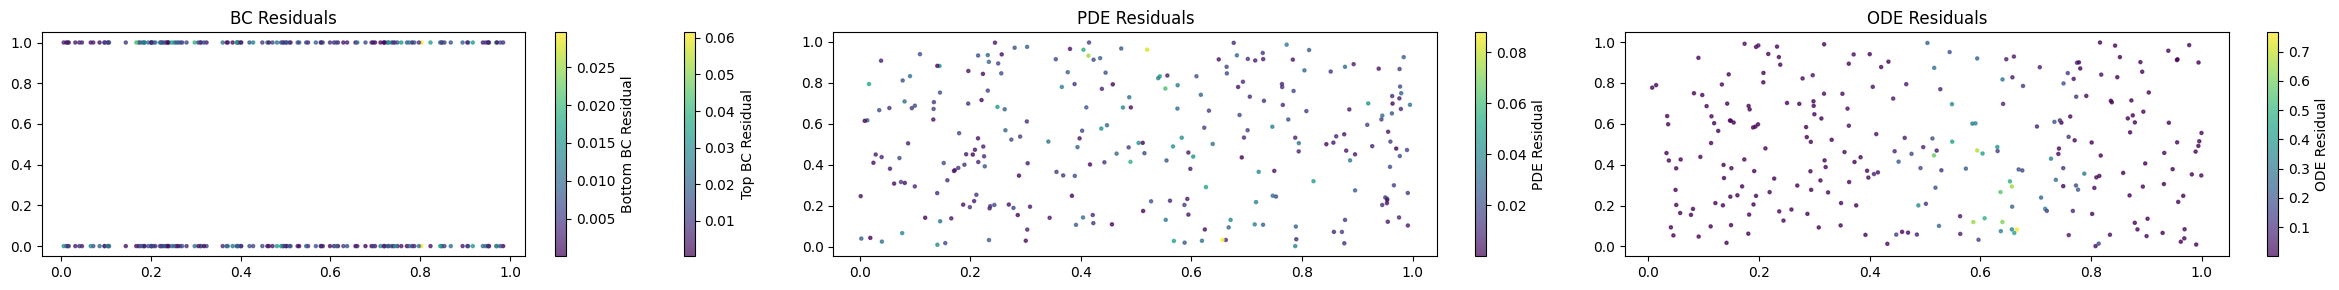

Training Progress:  35%|█████████████████████████████████████████████████████████████▌                                                                                                                  | 70/200 [33:09<48:11, 22.24s/it, Status=** Training T **, Loss T=1.34e-02, Loss a=6.21e-05, ICs T=1.08e-05, ICs tool=7.35e-06, ICs Alpha=6.30e-07, BCs Bot=4.71e-05, BCs Top=4.08e-04, PDE Part=1.02e-02, PDE Tool=1.04e-04, Cure Part=6.14e-05, INF=6.90e-04, FLUX=1.61e-04, T lr=2.06e-04, a lr=1.21e-04]

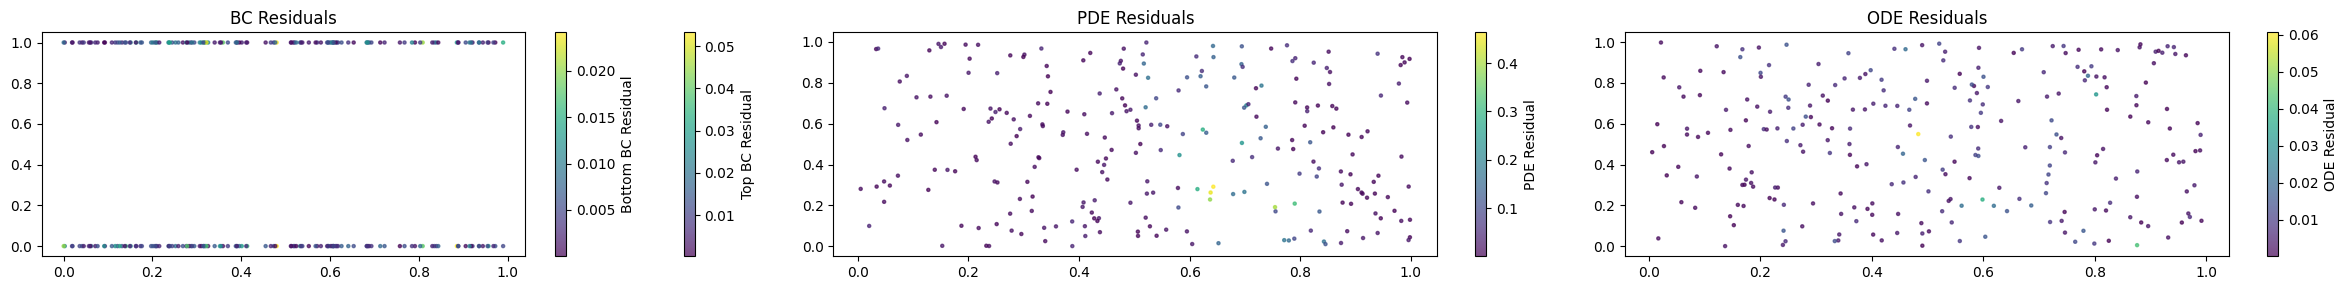

Training Progress:  40%|█████████████████████████████████████████████████████████████████████▌                                                                                                        | 80/200 [39:17<1:13:34, 36.79s/it, Status=** Training a **, Loss T=2.85e-03, Loss a=2.88e-02, ICs T=7.88e-06, ICs tool=4.75e-06, ICs Alpha=6.31e-07, BCs Bot=4.37e-05, BCs Top=2.33e-04, PDE Part=6.08e-04, PDE Tool=6.27e-05, Cure Part=2.88e-02, INF=6.04e-04, FLUX=1.57e-04, T lr=1.21e-04, a lr=1.21e-04]

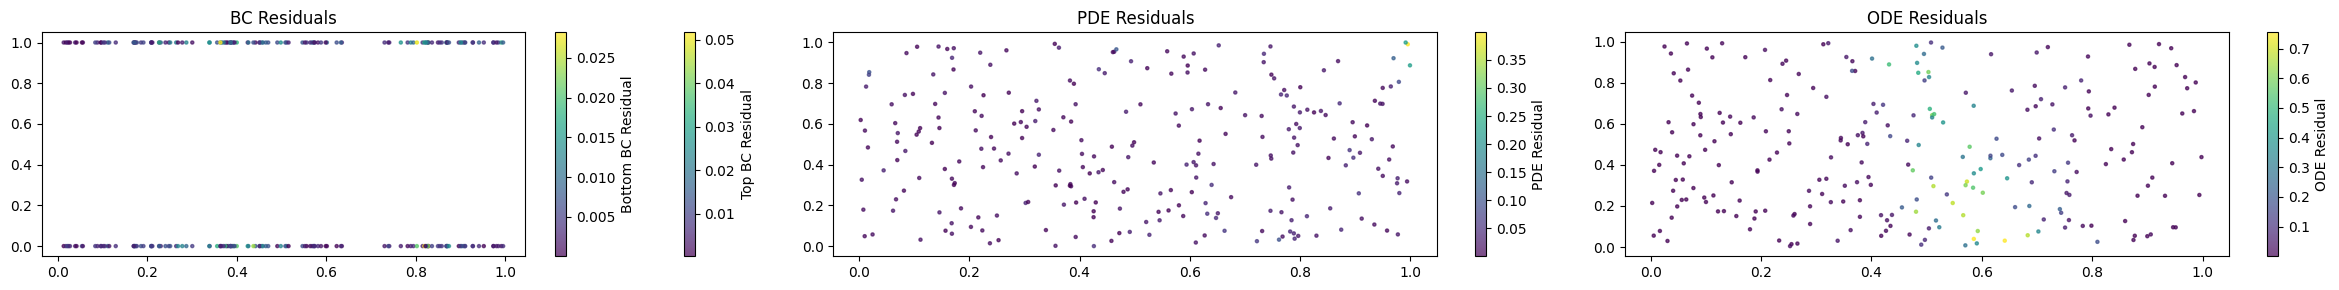

Training Progress:  45%|███████████████████████████████████████████████████████████████████████████████▏                                                                                                | 90/200 [43:02<42:18, 23.07s/it, Status=** Training T **, Loss T=2.46e-02, Loss a=1.30e-04, ICs T=8.84e-06, ICs tool=4.68e-06, ICs Alpha=5.70e-07, BCs Bot=4.20e-05, BCs Top=2.29e-04, PDE Part=2.24e-02, PDE Tool=7.00e-05, Cure Part=1.29e-04, INF=6.55e-04, FLUX=1.25e-04, T lr=1.21e-04, a lr=7.16e-05]

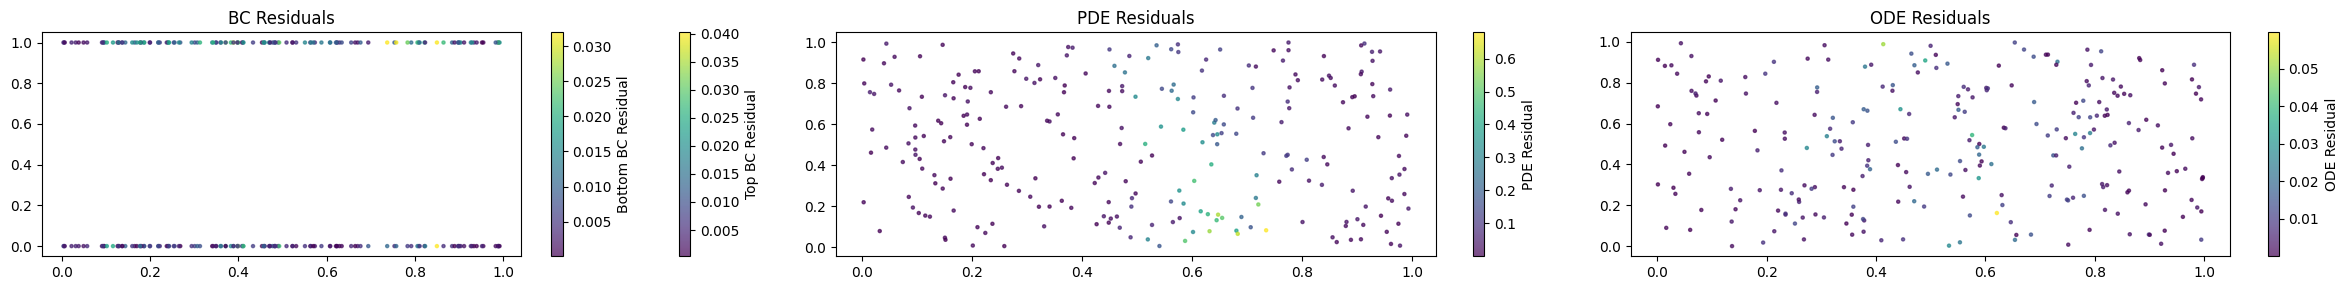

Training Progress:  50%|██████████████████████████████████████████████████████████████████████████████████████▌                                                                                      | 100/200 [49:30<1:02:53, 37.74s/it, Status=** Training a **, Loss T=2.36e-03, Loss a=4.53e-02, ICs T=5.38e-06, ICs tool=3.90e-06, ICs Alpha=5.67e-07, BCs Bot=3.99e-05, BCs Top=2.26e-04, PDE Part=3.39e-04, PDE Tool=6.02e-05, Cure Part=4.53e-02, INF=4.75e-04, FLUX=1.36e-04, T lr=7.16e-05, a lr=7.16e-05]

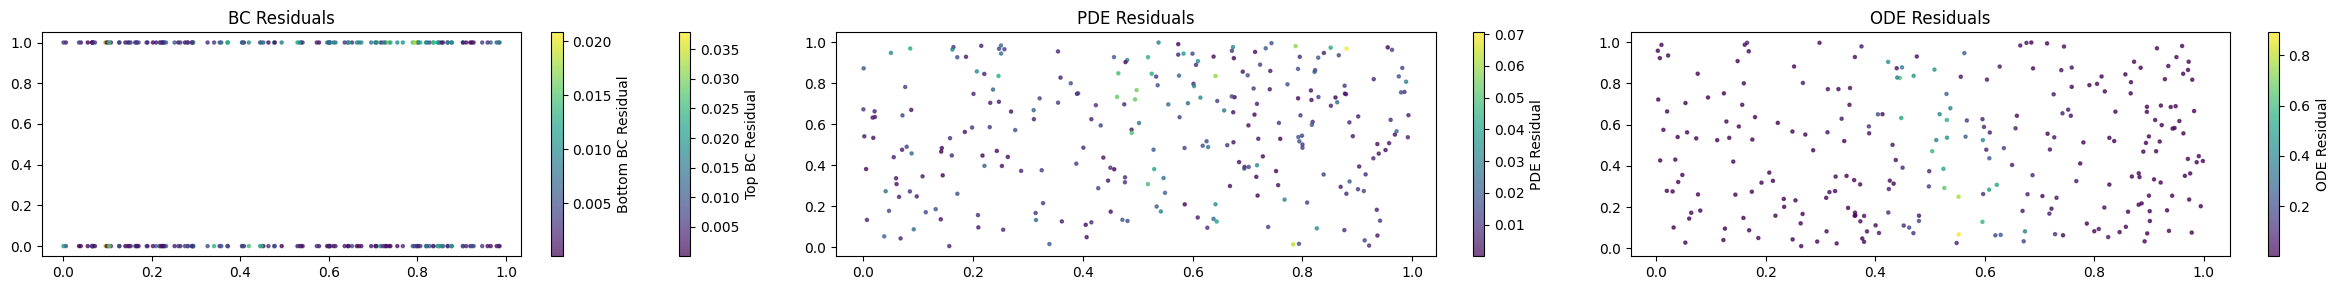

Training Progress:  55%|████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                              | 110/200 [53:20<35:22, 23.58s/it, Status=** Training T **, Loss T=1.97e-02, Loss a=1.77e-04, ICs T=6.35e-06, ICs tool=3.96e-06, ICs Alpha=4.65e-07, BCs Bot=2.97e-05, BCs Top=1.99e-04, PDE Part=1.80e-02, PDE Tool=5.49e-05, Cure Part=1.77e-04, INF=3.71e-04, FLUX=1.34e-04, T lr=7.16e-05, a lr=4.23e-05]

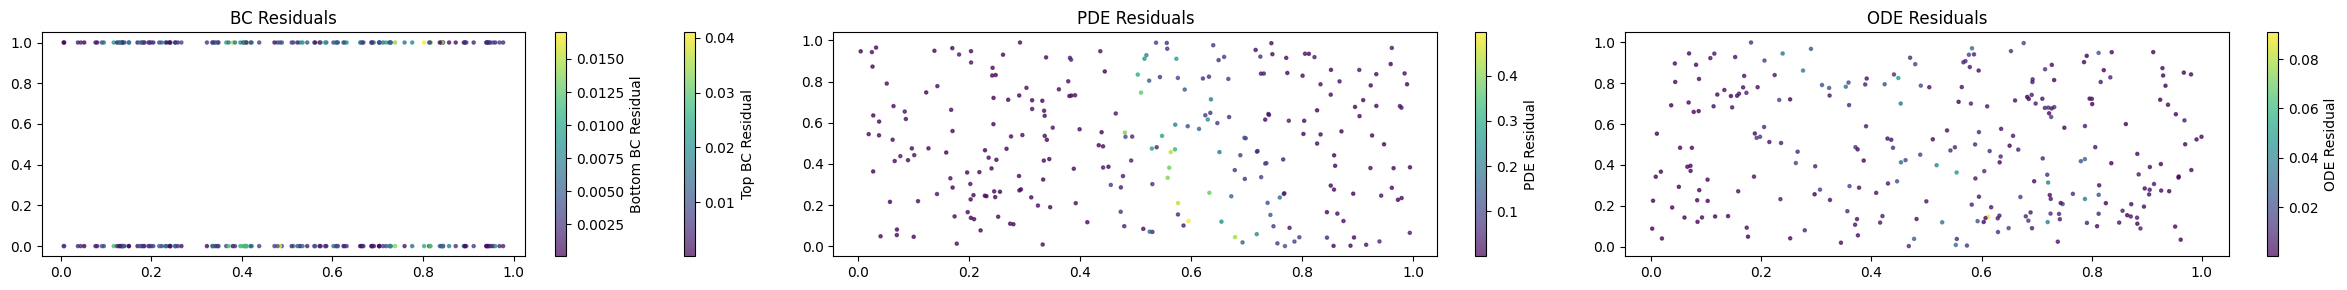

Training Progress:  60%|█████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                      | 120/200 [59:45<50:46, 38.09s/it, Status=** Training a **, Loss T=1.96e-03, Loss a=1.06e-02, ICs T=6.94e-06, ICs tool=3.11e-06, ICs Alpha=4.77e-07, BCs Bot=2.99e-05, BCs Top=1.88e-04, PDE Part=3.51e-04, PDE Tool=5.70e-05, Cure Part=1.06e-02, INF=3.62e-04, FLUX=7.29e-05, T lr=4.23e-05, a lr=4.23e-05]

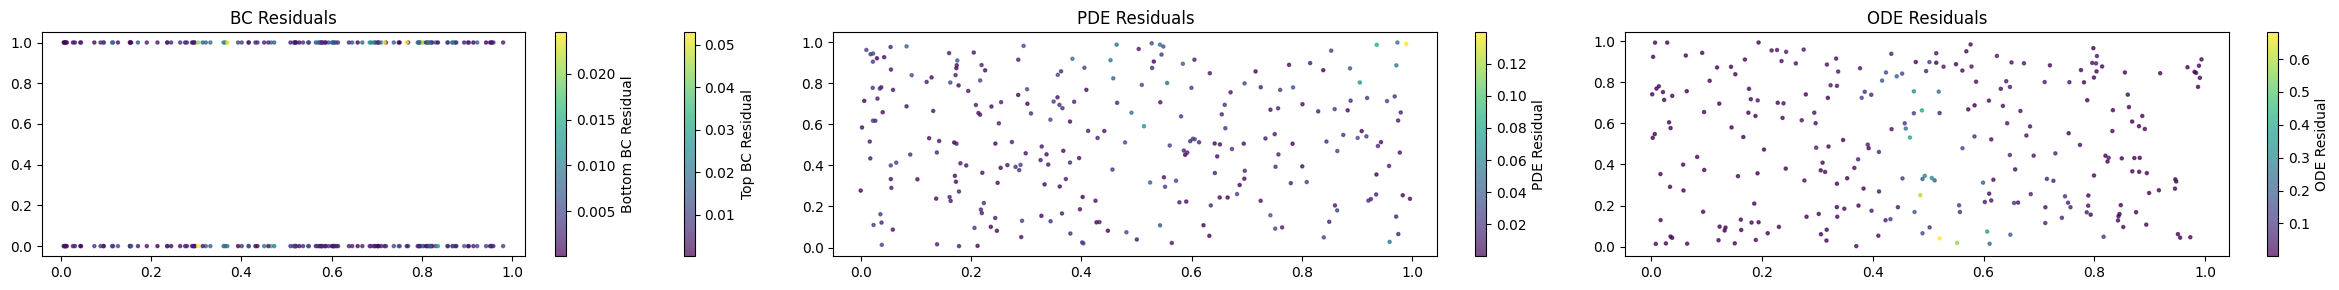

Training Progress:  65%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                                            | 130/200 [1:03:34<27:06, 23.23s/it, Status=** Training T **, Loss T=5.13e-03, Loss a=2.15e-04, ICs T=6.50e-06, ICs tool=3.32e-06, ICs Alpha=4.03e-07, BCs Bot=2.41e-05, BCs Top=1.49e-04, PDE Part=3.76e-03, PDE Tool=4.56e-05, Cure Part=2.14e-04, INF=3.55e-04, FLUX=7.89e-05, T lr=4.23e-05, a lr=2.49e-05]

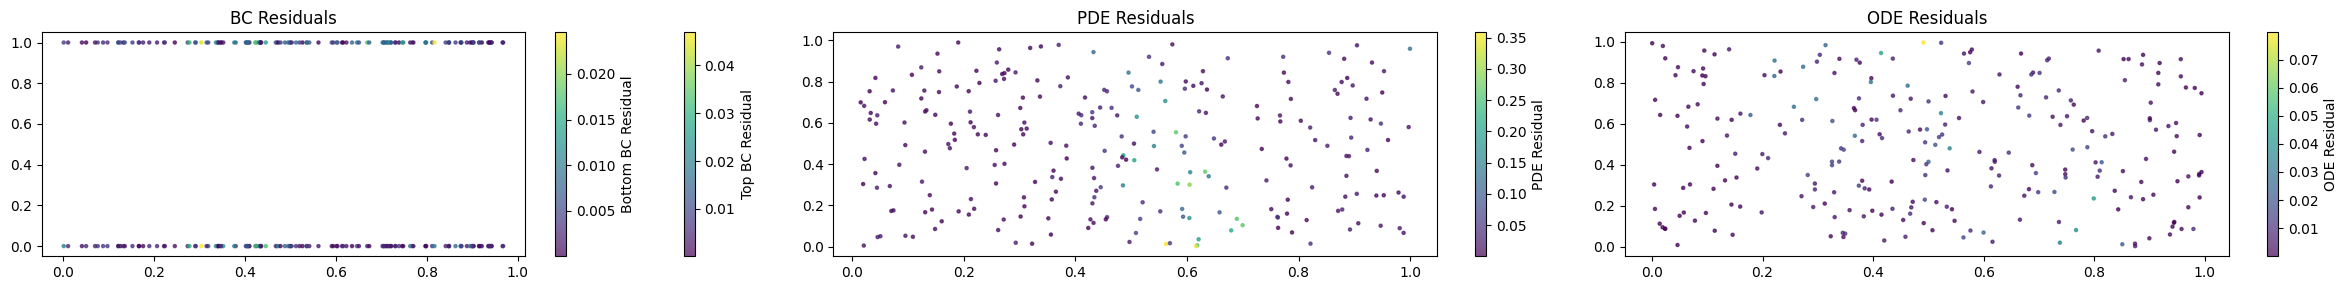

Training Progress:  70%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                    | 140/200 [1:09:59<37:57, 37.95s/it, Status=** Training a **, Loss T=1.57e-03, Loss a=2.46e-03, ICs T=4.85e-06, ICs tool=2.80e-06, ICs Alpha=4.05e-07, BCs Bot=1.68e-05, BCs Top=1.87e-04, PDE Part=1.76e-04, PDE Tool=3.31e-05, Cure Part=2.46e-03, INF=2.44e-04, FLUX=7.87e-05, T lr=2.49e-05, a lr=2.49e-05]

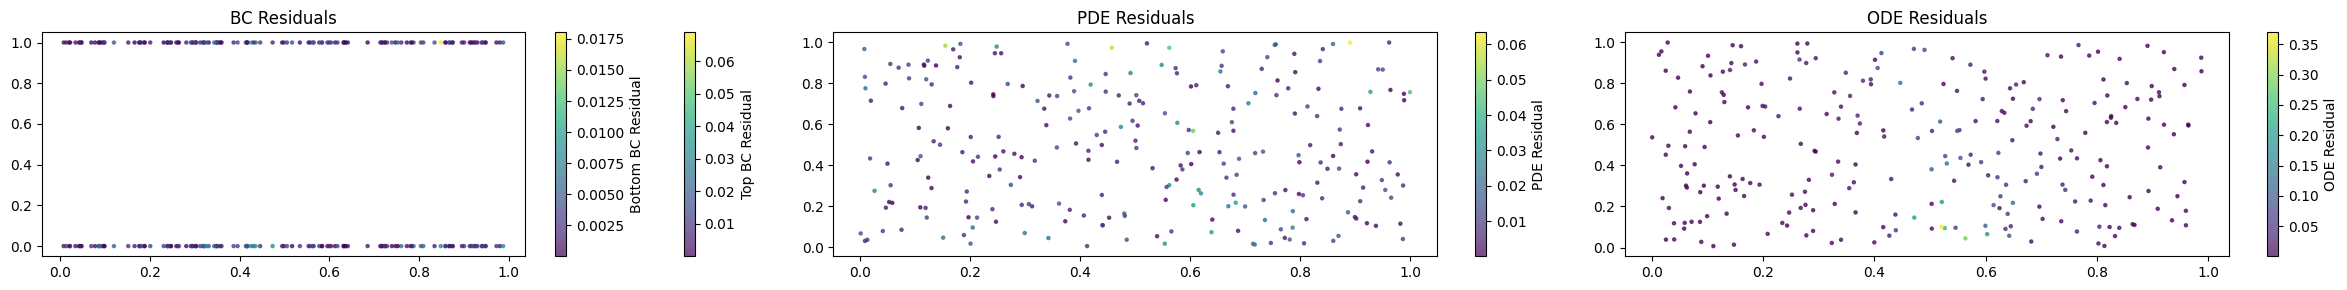

Training Progress:  75%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                           | 150/200 [1:13:50<19:30, 23.41s/it, Status=** Training T **, Loss T=2.22e-03, Loss a=1.78e-04, ICs T=4.92e-06, ICs tool=3.00e-06, ICs Alpha=3.93e-07, BCs Bot=2.63e-05, BCs Top=1.44e-04, PDE Part=8.42e-04, PDE Tool=3.60e-05, Cure Part=1.78e-04, INF=4.01e-04, FLUX=7.20e-05, T lr=2.49e-05, a lr=1.47e-05]

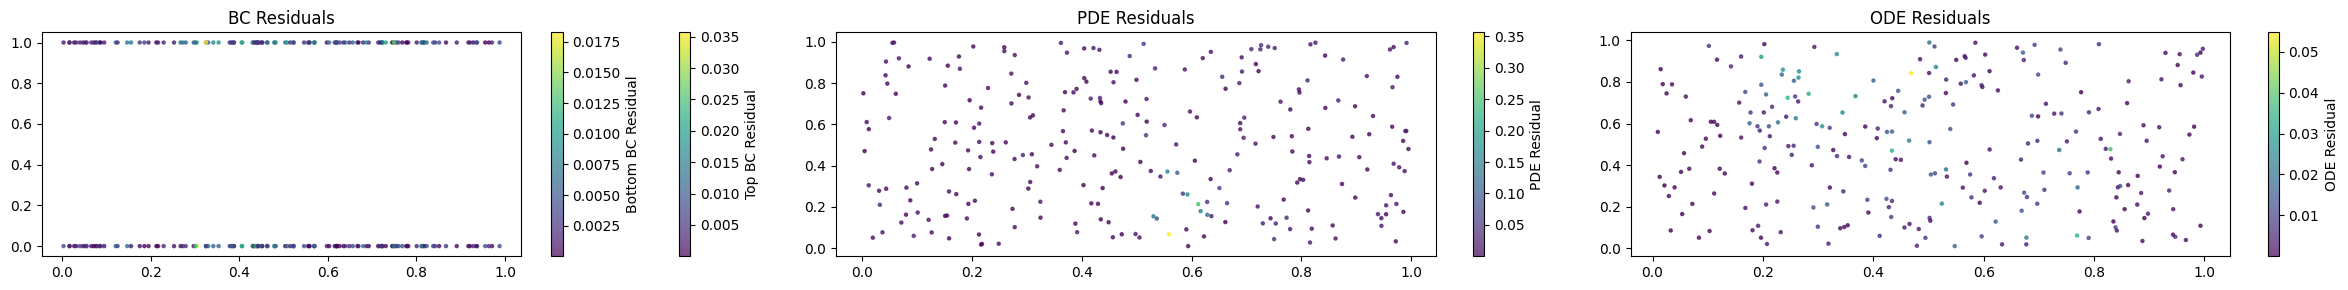

Training Progress:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                  | 160/200 [1:20:18<25:15, 37.88s/it, Status=** Training a **, Loss T=1.49e-03, Loss a=1.83e-03, ICs T=4.03e-06, ICs tool=2.71e-06, ICs Alpha=3.92e-07, BCs Bot=2.12e-05, BCs Top=1.69e-04, PDE Part=1.82e-04, PDE Tool=3.54e-05, Cure Part=1.83e-03, INF=2.45e-04, FLUX=6.46e-05, T lr=1.47e-05, a lr=1.47e-05]

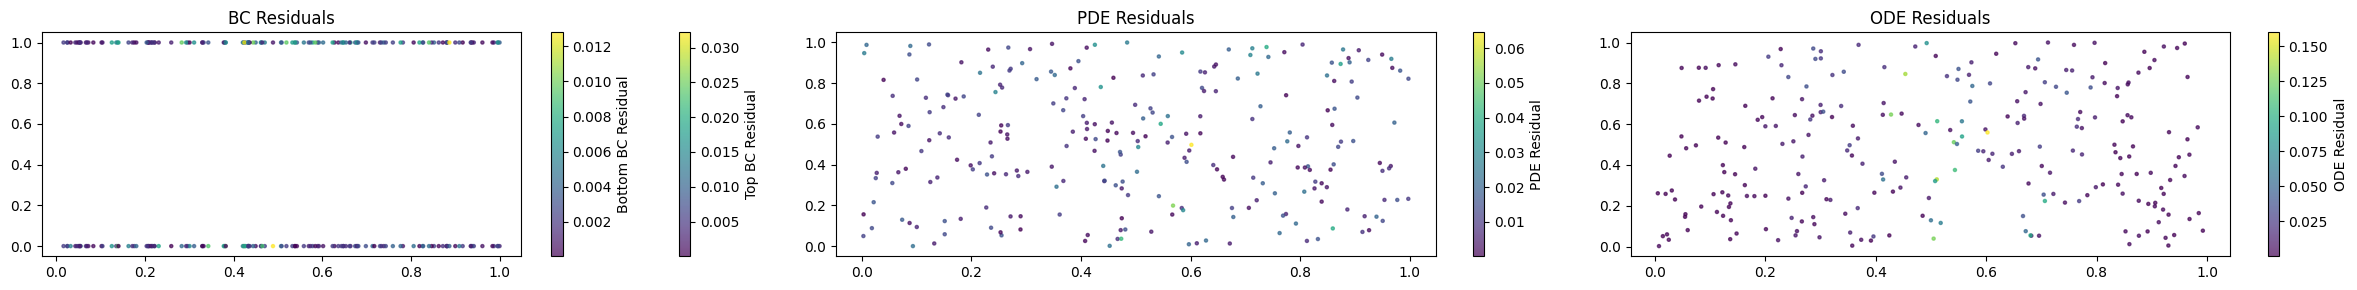

Training Progress:  85%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                          | 170/200 [1:24:10<11:39, 23.32s/it, Status=** Training T **, Loss T=2.06e-03, Loss a=2.06e-04, ICs T=4.03e-06, ICs tool=2.80e-06, ICs Alpha=3.94e-07, BCs Bot=1.70e-05, BCs Top=1.73e-04, PDE Part=7.72e-04, PDE Tool=4.00e-05, Cure Part=2.05e-04, INF=2.17e-04, FLUX=6.56e-05, T lr=1.47e-05, a lr=8.69e-06]

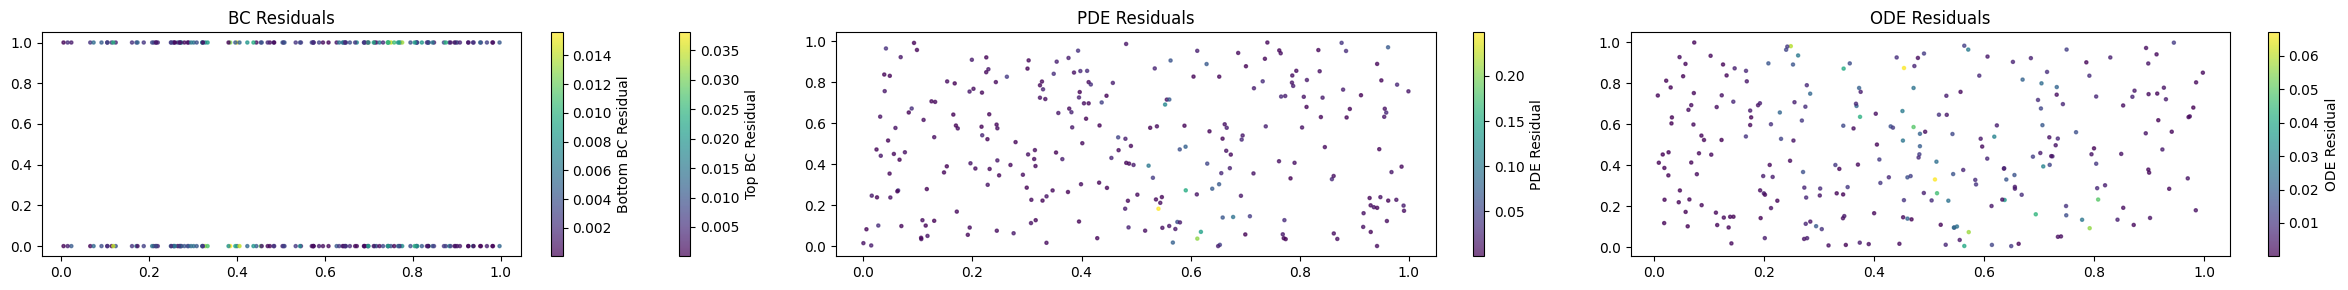

Training Progress:  90%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                 | 180/200 [1:30:42<12:58, 38.95s/it, Status=** Training a **, Loss T=1.44e-03, Loss a=8.97e-04, ICs T=4.47e-06, ICs tool=2.55e-06, ICs Alpha=3.99e-07, BCs Bot=1.34e-05, BCs Top=1.65e-04, PDE Part=1.89e-04, PDE Tool=3.12e-05, Cure Part=8.97e-04, INF=2.43e-04, FLUX=6.76e-05, T lr=8.69e-06, a lr=8.69e-06]

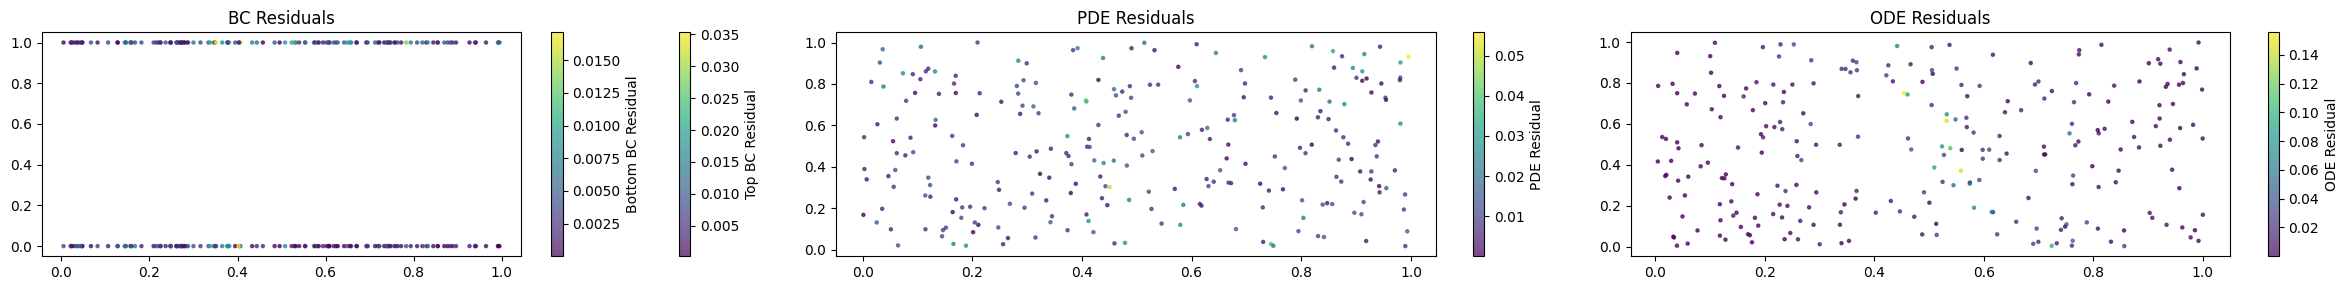

Training Progress:  95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎        | 190/200 [1:34:32<03:57, 23.71s/it, Status=** Training T **, Loss T=1.60e-03, Loss a=1.39e-04, ICs T=4.97e-06, ICs tool=2.56e-06, ICs Alpha=4.04e-07, BCs Bot=1.09e-05, BCs Top=1.27e-04, PDE Part=6.33e-04, PDE Tool=3.15e-05, Cure Part=1.39e-04, INF=1.72e-04, FLUX=5.49e-05, T lr=8.69e-06, a lr=5.13e-06]

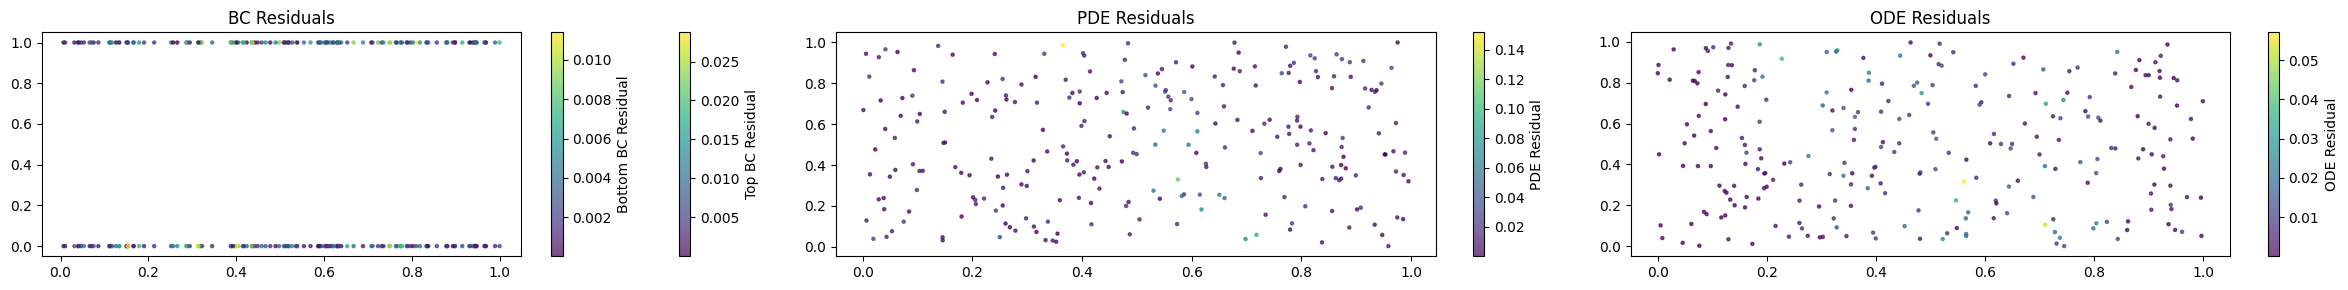

Training Progress: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [1:40:59<00:00, 30.30s/it, Status=** Training a **, Loss T=1.30e-03, Loss a=1.21e-03, ICs T=4.20e-06, ICs tool=2.51e-06, ICs Alpha=4.01e-07, BCs Bot=9.97e-06, BCs Top=1.30e-04, PDE Part=2.10e-04, PDE Tool=3.13e-05, Cure Part=1.21e-03, INF=2.79e-04, FLUX=6.30e-05, T lr=5.13e-06, a lr=5.13e-06]



Models saved for converged subdomain 0.00 - 1.00
Saved as xpidon_class_00_T.pkl and xpidon_class_00_a.pkl

Models saved for converged subdomain 0.00 - 1.00
Saved as outputs/models/xpidon_class_10000_T.pkl and outputs/models/xpidon_class_10000_a.pkl
Loss history saved as outputs/loss_data/loss_history_10000.pkl

--- Domain Decomposition Training Complete ---


In [6]:
train(XPIDON, XPIDONLoss, generate_training_data, DataGenerator, Temp_air,params,exp_params,train_params,init_sub_domain,Tolerance_level,m_inp,
          branch_layers ,trunk_layers, nomad_layers_T)

In [7]:
%run plot_training_results.py

Using loss files:
  outputs/loss_data/loss_history_10000.pkl

Merged loss length:
loss_T 1100
loss_a 1100
loss_ics_T 1100
loss_ics_tool 1100
loss_ics_a 1100
loss_bct 1100
loss_bcb 1100
loss_res 1100
loss_res_tool 1100
loss_ode 1100
loss_inf 1100
loss_flux 1100
Saved: outputs/loss_data/loss_history_merged.pkl
Saved: outputs/figures/temperature_network_loss.png
Saved: outputs/figures/doc_network_loss.png

Using model tags:
10000 outputs/models/xpidon_class_10000_T.pkl outputs/models/xpidon_class_10000_a.pkl
Saved: outputs/predictions/final_temperature_doc_prediction.pkl
Saved: outputs/predictions/final_temperature_doc_prediction.csv
Saved: outputs/figures/final_temperature_doc_prediction.png

Done. All generated files are inside outputs/.


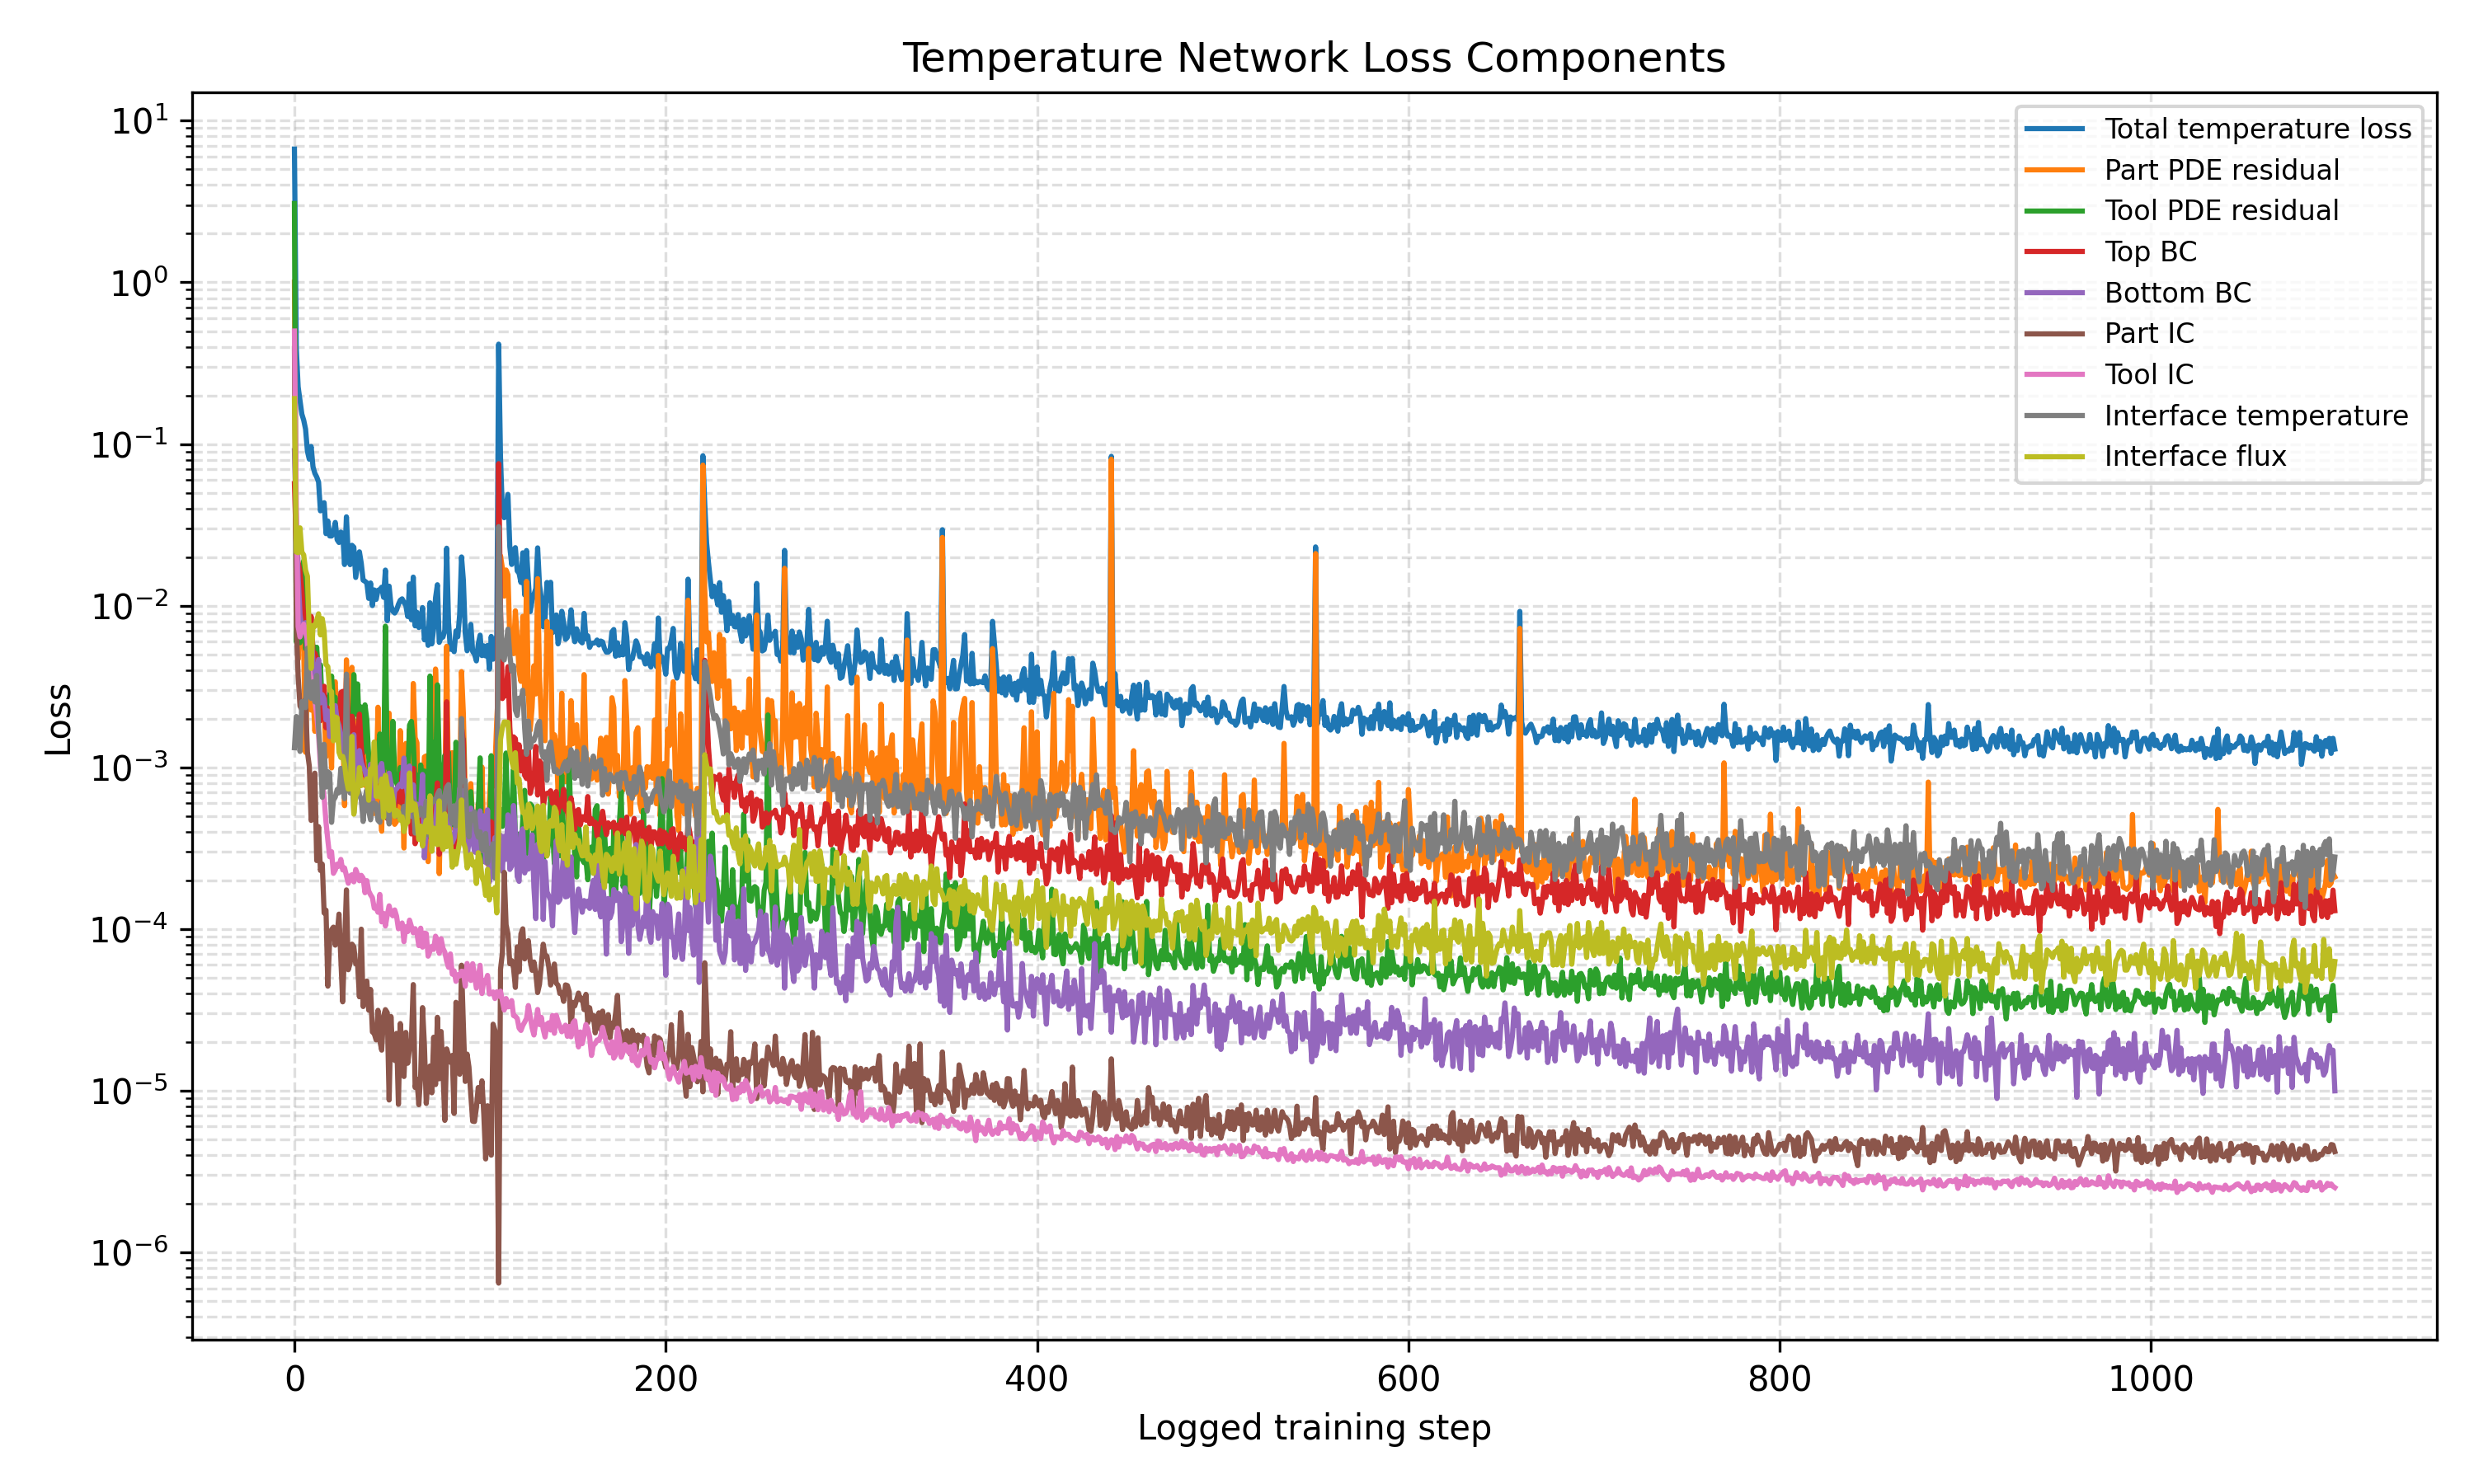

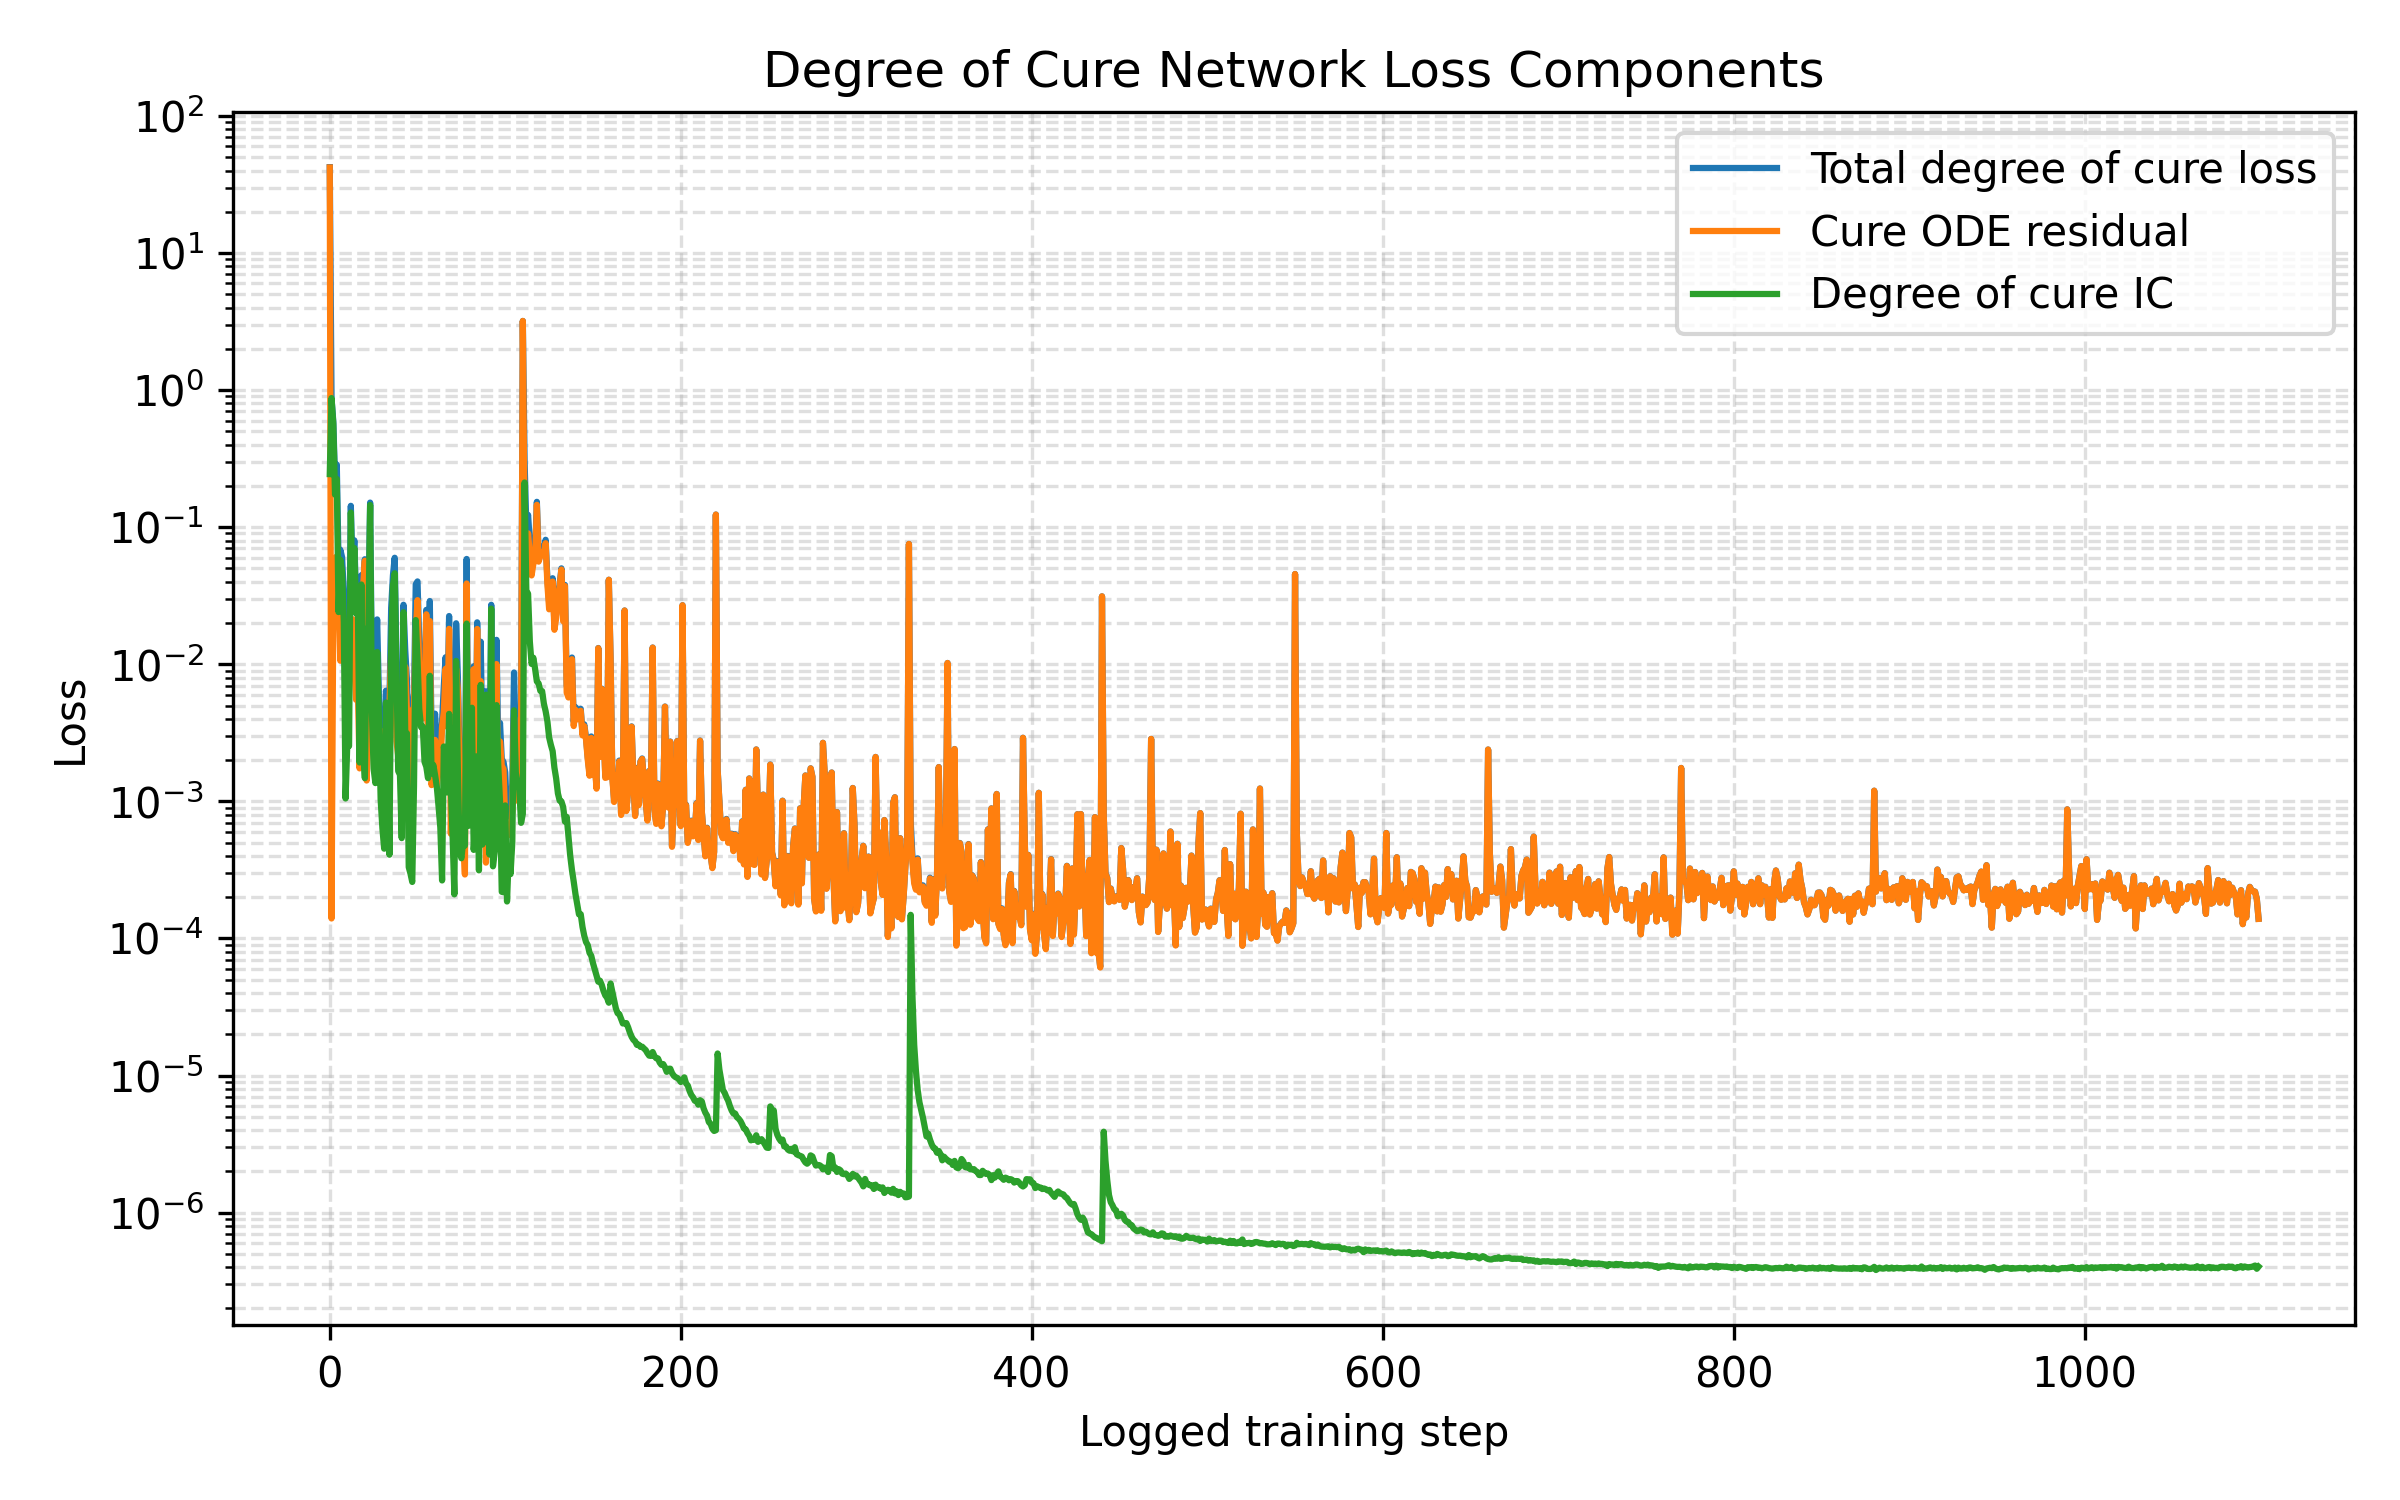

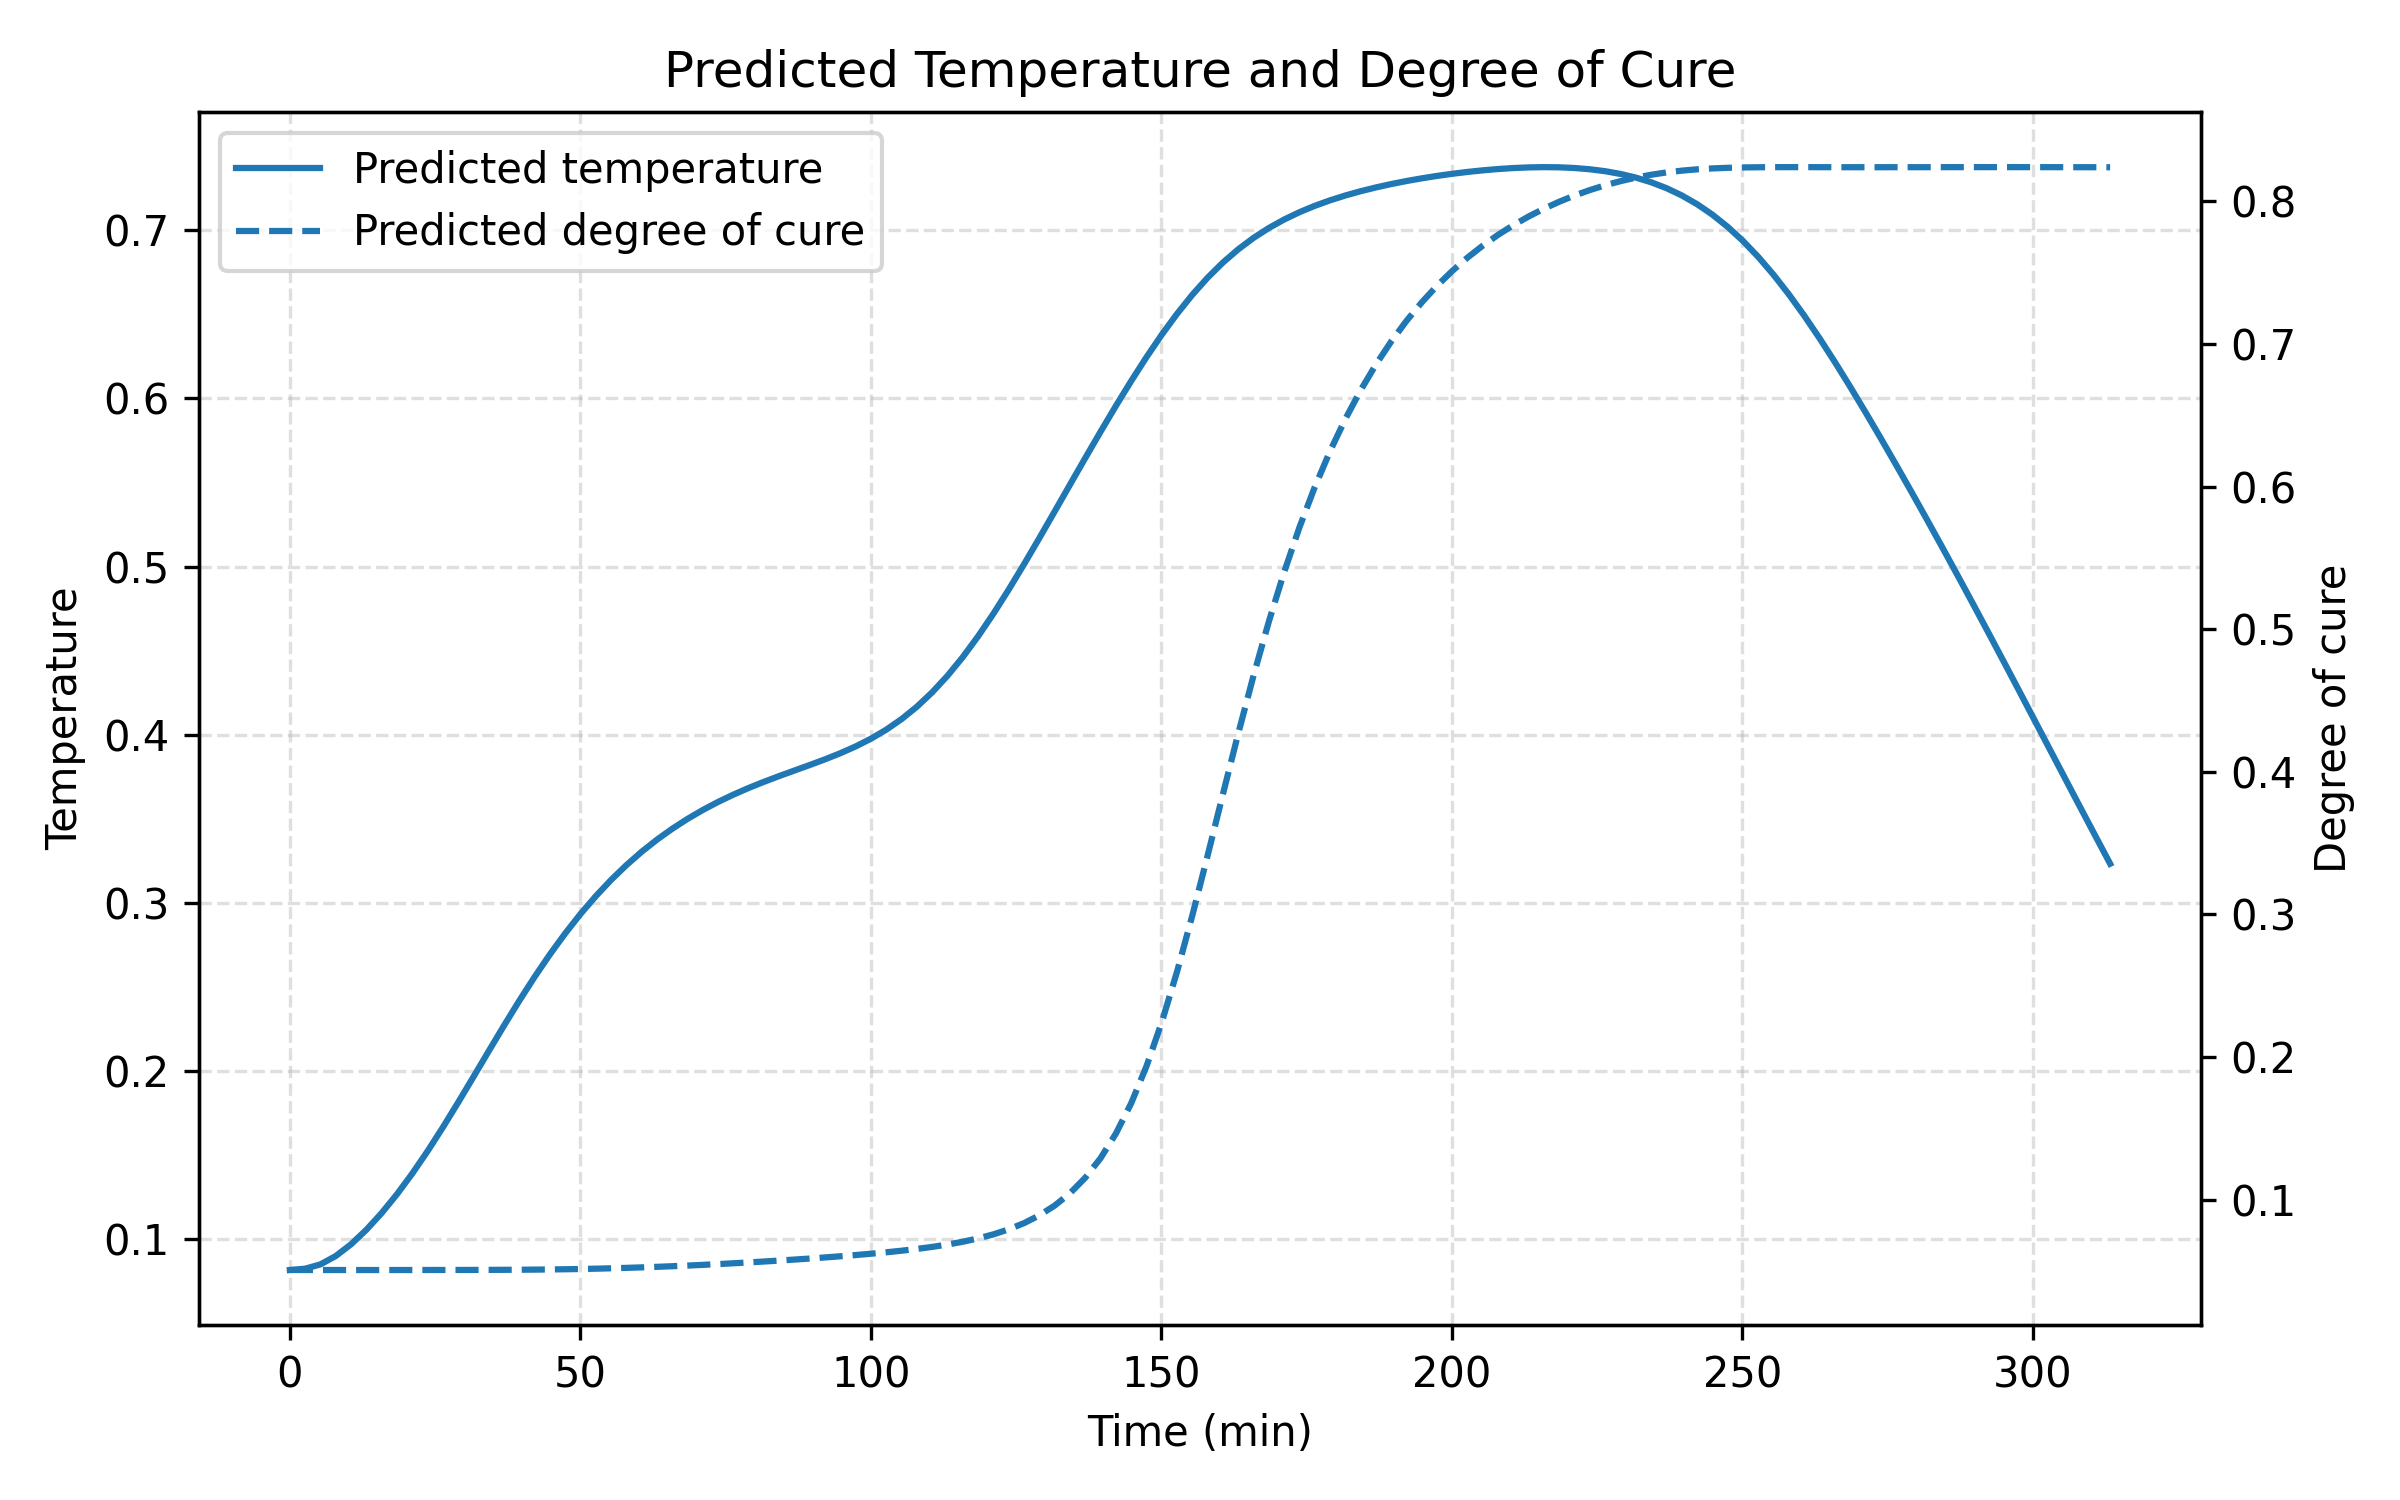

In [8]:

from IPython.display import Image, display

display(Image("outputs/figures/temperature_network_loss.png"))
display(Image("outputs/figures/doc_network_loss.png"))
display(Image("outputs/figures/final_temperature_doc_prediction.png"))

In [9]:
from pathlib import Path

print("Model tags:")
for f in sorted(Path("outputs/models").glob("xpidon_class_*_T.pkl")):
    print(f.name)

print("\nLoss files:")
for f in sorted(Path("outputs/loss_data").glob("loss_history_*.pkl")):
    print(f.name)

Model tags:
xpidon_class_10000_T.pkl

Loss files:
loss_history_10000.pkl
loss_history_merged.pkl
